[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/PO_II/blob/main/05_FluxoMaximo.ipynb)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Cria um objeto de grafo direcionado
G = nx.DiGraph()

# Adiciona nós ao grafo
G.add_node('s')  # Nó fonte
G.add_node('a')
G.add_node('b')
G.add_node('c')
G.add_node('d')
G.add_node('t')  # Nó destino

# Adiciona arestas ao grafo com suas capacidades
G.add_edge('s', 'a', capacidade=3)
G.add_edge('s', 'b', capacidade=2)
G.add_edge('a', 'b', capacidade=1)
G.add_edge('a', 'c', capacidade=3)
G.add_edge('b', 'd', capacidade=2)
G.add_edge('c', 'd', capacidade=2)
G.add_edge('c', 't', capacidade=3)
G.add_edge('d', 't', capacidade=3)


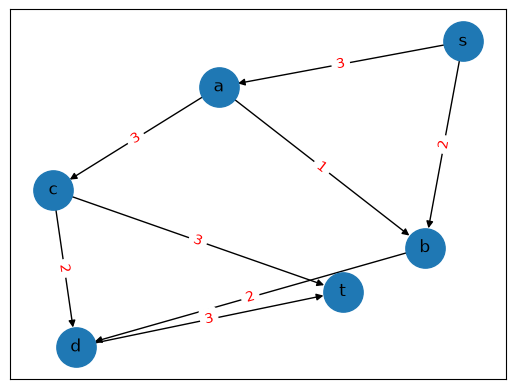

In [3]:
# Desenha o grafo com os rótulos de capacidade nas arestas

pos =  nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size = 800)
aresta_rotulos = {(u, v): d['capacidade'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=aresta_rotulos, font_color='red')
plt.show()


### Fluxo Máximo

In [4]:
# Calcula o fluxo máximo
fluxo_max, fluxo_dict = nx.maximum_flow(G, 's', 't', capacity = 'capacidade')


In [5]:
# Imprime os resultados
print("Fluxo máximo:", fluxo_max)
print("Dicionário de fluxo:", fluxo_dict)


Fluxo máximo: 5
Dicionário de fluxo: {'s': {'a': 3, 'b': 2}, 'a': {'b': 0, 'c': 3}, 'b': {'d': 2}, 'c': {'d': 0, 't': 3}, 'd': {'t': 2}, 't': {}}


### Corte Mínimo

In [6]:
# Corte mínimo
corte_min, part = nx.minimum_cut(G, 's', 't', capacity = 'capacidade')

In [7]:
# Imprime os resultados
print("Valor do Corte Mínimo:", corte_min)
print("Partição dos vértices a partir do corte mínimo:", part)


Valor do Corte Mínimo: 5
Partição dos vértices a partir do corte mínimo: ({'a', 's', 'b'}, {'d', 'c', 't'})


## Vários destinos: o **super-destino**

O algoritmo de fluxo máximo trabalha com **uma** origem e **um** destino. E quando o problema tem mais de um destino?

**Problema.** Uma fábrica **F** precisa escoar sua produção diária para **dois** centros de distribuição, **CD1** e **CD2**, através de uma malha rodoviária com três entroncamentos: **A**, **B** e **C**. As capacidades dos trechos, em caminhões por dia, são:

| Trecho | F→A | F→B | A→B | A→C | A→CD1 | B→C | B→CD2 | C→CD1 |
|:---|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
| **Capacidade** | 8 | 6 | 3 | 5 | 2 | 4 | 4 | 6 |

Além disso, cada centro tem um limite diário de recepção: o **CD1** consegue descarregar no máximo **7** caminhões por dia e o **CD2**, no máximo **6**.

Quantos caminhões, no máximo, podem sair da fábrica por dia?

Como temos **dois** destinos, não podemos chamar `nx.maximum_flow` diretamente. A saída é uma técnica de modelagem: criamos um **vértice artificial $T$**, o *super-destino* (ou *super-sumidouro*), e ligamos **cada destino real a $T$**.

E qual capacidade dar a esses arcos artificiais? Justamente o **limite de recepção de cada destino**:

- $CD1 \rightarrow T$ com capacidade $7$;
- $CD2 \rightarrow T$ com capacidade $6$.

Assim, o fluxo máximo de $F$ até $T$ é exatamente o total que a fábrica consegue escoar, e o fluxo em cada arco artificial nos diz quanto cada centro recebeu.


A mesma ideia vale, simetricamente, para **várias origens**: cria-se uma **super-fonte** $S$ com arcos $S \rightarrow$ (cada origem real).

In [ ]:
# Grafo com DOIS destinos reais (CD1 e CD2) + o super-destino T

G2 = nx.DiGraph()

# --- Arcos reais: a malha rodoviária ---
G2.add_edge('F', 'A', capacidade = 8)
G2.add_edge('F', 'B', capacidade = 6)
G2.add_edge('A', 'B', capacidade = 3)
G2.add_edge('A', 'C', capacidade = 5)
G2.add_edge('A', 'CD1', capacidade = 2)
G2.add_edge('B', 'C', capacidade = 4)
G2.add_edge('B', 'CD2', capacidade = 4)
G2.add_edge('C', 'CD1', capacidade = 6)

# --- Arcos ARTIFICIAIS: ligam cada destino real ao super-destino T ---
# a capacidade de cada um e o limite de recepcao do centro de distribuicao
G2.add_edge('CD1', 'T', capacidade = 7)
G2.add_edge('CD2', 'T', capacidade = 6)

print("Vértices:", list(G2.nodes()))
print("Arcos artificiais:", [(i, j) for i, j in G2.edges() if j == 'T'])

In [ ]:
# Desenhando a rede: em verde tracejado, a parte artificial do modelo

pos2 = {'F': (0, 1), 'A': (1, 2), 'B': (1, 0), 'C': (2, 1),
        'CD1': (3, 2), 'CD2': (3, 0), 'T': (4, 1)}

reais       = [(i, j) for i, j in G2.edges() if j != 'T']
artificiais = [(i, j) for i, j in G2.edges() if j == 'T']

plt.figure(figsize = (9, 5))

nx.draw_networkx_nodes(G2, pos2, node_size = 900, node_color = 'lightblue')
nx.draw_networkx_nodes(G2, pos2, nodelist = ['T'], node_size = 900, node_color = 'lightgreen')
nx.draw_networkx_labels(G2, pos2)

nx.draw_networkx_edges(G2, pos2, edgelist = reais, node_size = 900)
nx.draw_networkx_edges(G2, pos2, edgelist = artificiais, node_size = 900,
                       style = 'dashed', edge_color = 'green')

rotulos2 = {(i, j): d['capacidade'] for i, j, d in G2.edges(data = True)}
nx.draw_networkx_edge_labels(G2, pos2, edge_labels = rotulos2, font_color = 'red')

plt.title("Arcos tracejados: artificiais (super-destino T)")
plt.axis('off')
plt.show()

In [ ]:
# Agora sim, com uma unica origem (F) e um unico destino (T), podemos resolver

fluxo_max2, fluxo_dict2 = nx.maximum_flow(G2, 'F', 'T', capacity = 'capacidade')

print("Total escoado pela fábrica:", fluxo_max2, "caminhões/dia\n")

print("Recebido em CD1:", fluxo_dict2['CD1']['T'])
print("Recebido em CD2:", fluxo_dict2['CD2']['T'])

print("\nFluxo em cada trecho:")
for i in fluxo_dict2:
    for j, x in fluxo_dict2[i].items():
        if x > 0:
            print(f"  {i} -> {j} = {x}")

In [ ]:
# O corte minimo tambem funciona normalmente

corte_min2, part2 = nx.minimum_cut(G2, 'F', 'T', capacity = 'capacidade')

print("Valor do corte mínimo:", corte_min2)
print("Partição:", part2)

S, Tp = part2
print("\nArcos do corte:", [(i, j) for i, j in G2.edges() if i in S and j in Tp])

**Lendo o resultado.** A fábrica consegue escoar **11 caminhões por dia**: 7 para o CD1 e 4 para o CD2.

Repare em duas coisas interessantes:

- O **CD1 chegou ao seu limite** de recepção (7). Já o **CD2 recebeu apenas 4**, embora pudesse receber 6. Quem o limitou não foi a sua capacidade de descarga, e sim o trecho $B \rightarrow CD2$, que comporta só 4 caminhões.
- Por isso, o corte mínimo é formado por **um arco real e um arco artificial**: $\{B \rightarrow CD2,\, CD1 \rightarrow T\}$, com capacidade $4 + 7 = 11$. Ou seja, para aumentar o escoamento seria preciso agir nas **duas** frentes: alargar a estrada até o CD2 **e** ampliar a capacidade de descarga do CD1. Mexer em apenas uma delas não adianta.

Se os limites de recepção não existissem (arcos artificiais com capacidade infinita), o fluxo máximo subiria para 12 caminhões/dia — vale a pena testar!

# Exercício 1

Encontre o padrão de Fluxo Máximo entre os vértices O e T. Considere como capacidade. Encontre um corte mínimo. Como o corte mínimo particiona os vértices?


<center> <img src="Figuras/fluxomax_aula.png"> </center>

In [ ]:
# Escreva seu código aqui

# Exercício 2

Encontre o padrão de Fluxo Máximo entre os vértices A e F. Considere como capacidade. Encontre um corte mínimo. Como o corte mínimo particiona os vértices?


<center> <img src="Figuras/fluxomax_1.png"> </center>

In [ ]:
# Escreva seu código aqui

# Exercício 3


Encontre o padrão de Fluxo Máximo entre os vértices source e sink. Considere como capacidade. Encontre o corte mínimo. Como o corte mínimo particiona os vértices?

<center> <img src="Figuras/fluxomax_exercicio3.png"> </center>

In [ ]:
# Escreva seu código aqui